## 8. Putting it all together by building a multi-class classification model.

(Date - 5/Apr/2026)

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from helper_functions import plot_decision_boundary
from torchmetrics import Accuracy

### 8.1 Creating a toy multi-class dataset

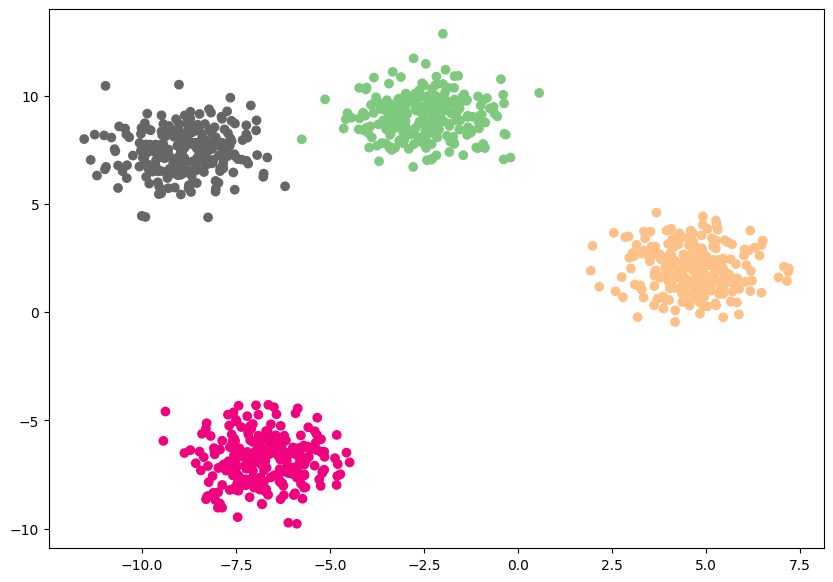

In [2]:
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob, Y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            cluster_std=1,
                            centers=NUM_CLASSES,
                            random_state=RANDOM_SEED)

X_blob = torch.from_numpy(X_blob).type(torch.float)
Y_blob = torch.from_numpy(Y_blob).type(torch.LongTensor)

X_blob_train, X_blob_test, Y_blob_train, Y_blob_test = train_test_split(X_blob,
                                                                        Y_blob,
                                                                        test_size=0.2,
                                                                        random_state=RANDOM_SEED)




plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0], X_blob[:,1], c=Y_blob, cmap=plt.cm.Accent);

### 8.2 Building a multi-class classification model

(Date - 6/Apr/2026)

In [3]:
# Create a device agnostic code

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [4]:
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        
        """ 
        Initializes all required hyperparameters for a multi-class classification model.

        Args:
            input_features (int): Number of input features to the model.
            out_features (int): Number of output features of the model
              (how many classes there are).
            hidden_units (int): Number of hidden units between layers, default 8.
        """
        super().__init__()

        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_features)  
        )
    
    def forward(self, x):
        return self.linear_layer_stack(x)


blob_model = BlobModel(input_features=2, output_features=4, hidden_units=8).to(device)
blob_model


BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [5]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    accuracy = (correct / len(y_pred)) * 100 
    return accuracy

### 8.3 Creating a loss function and an optimizer

In [6]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=blob_model.parameters(),
                            lr=0.1)

### 8.4 Getting prediction probabilities for a multi-class PyTorch model

(Date - 7/Apr/2026)

In [7]:
blob_model.eval()
with torch.inference_mode():
    y_logits = blob_model(X_blob_train).to(device)

y_logits[:5]

tensor([[ 1.7881, -0.4035,  0.0539, -0.3495],
        [ 1.3386, -1.3823, -0.1430, -0.7267],
        [-3.1118,  1.8782, -1.3177, -0.2632],
        [-2.1787,  1.2953, -1.0654, -0.3278],
        [ 0.9495, -1.0982, -0.2457, -0.6865]])

In [8]:
y_logits.argmax(dim=1)[:100]

tensor([0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
        0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1,
        0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
        0, 0, 1, 0])

In [9]:
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[ 1.7881, -0.4035,  0.0539, -0.3495],
        [ 1.3386, -1.3823, -0.1430, -0.7267],
        [-3.1118,  1.8782, -1.3177, -0.2632],
        [-2.1787,  1.2953, -1.0654, -0.3278],
        [ 0.9495, -1.0982, -0.2457, -0.6865]])
tensor([[0.7111, 0.0795, 0.1255, 0.0839],
        [0.7043, 0.0464, 0.1601, 0.0893],
        [0.0058, 0.8582, 0.0351, 0.1008],
        [0.0234, 0.7561, 0.0713, 0.1492],
        [0.6148, 0.0793, 0.1861, 0.1197]])


In [10]:
torch.sum(y_pred_probs[0]) 

tensor(1.)

In [11]:
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds[:100]

tensor([0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
        0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1,
        0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
        0, 0, 1, 0])

In [12]:
Y_blob_test[:100]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2])

In [13]:
Y_blob_train[:10]

tensor([1, 0, 2, 2, 0, 0, 0, 1, 3, 0])

### 8.5 Creating a training and testing loop

(Date - 8/Apr/2026)

In [14]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 100

X_blob_train, Y_blob_train = X_blob_train.to(device), Y_blob_train.to(device)
X_blob_test, Y_blob_test = X_blob_test.to(device), Y_blob_test.to(device)

for epoch in range(epochs):
    blob_model.train()

    Y_logits = blob_model(X_blob_train)
    Y_pred = torch.softmax(Y_logits, dim = 1).argmax(dim=1)

    train_loss = loss_fn(Y_logits, Y_blob_train)
    acc = accuracy_fn(y_true=Y_blob_train,
                      y_pred = Y_pred)
    
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    blob_model.eval()
    with torch.inference_mode():
        test_logits = blob_model(X_blob_test)
        test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)

        test_loss = loss_fn(test_logits, Y_blob_test)
        test_acc = accuracy_fn(y_true=Y_blob_test,
                               y_pred=test_preds)
        
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {train_loss:.4f} | Acc: {acc:.2f} | Test Loss: {test_loss:.4f} | Test accuracy: {test_acc:.2f}")

Epoch: 0 | Loss: 1.7801 | Acc: 25.12 | Test Loss: 0.7512 | Test accuracy: 70.50
Epoch: 10 | Loss: 0.1352 | Acc: 99.88 | Test Loss: 0.1236 | Test accuracy: 100.00
Epoch: 20 | Loss: 0.0606 | Acc: 99.88 | Test Loss: 0.0564 | Test accuracy: 100.00
Epoch: 30 | Loss: 0.0364 | Acc: 99.88 | Test Loss: 0.0336 | Test accuracy: 100.00
Epoch: 40 | Loss: 0.0254 | Acc: 99.88 | Test Loss: 0.0231 | Test accuracy: 100.00
Epoch: 50 | Loss: 0.0194 | Acc: 99.88 | Test Loss: 0.0173 | Test accuracy: 100.00
Epoch: 60 | Loss: 0.0157 | Acc: 99.88 | Test Loss: 0.0137 | Test accuracy: 100.00
Epoch: 70 | Loss: 0.0132 | Acc: 99.88 | Test Loss: 0.0113 | Test accuracy: 100.00
Epoch: 80 | Loss: 0.0115 | Acc: 99.88 | Test Loss: 0.0096 | Test accuracy: 100.00
Epoch: 90 | Loss: 0.0101 | Acc: 99.88 | Test Loss: 0.0083 | Test accuracy: 100.00


In [21]:
Y_logits

tensor([[  5.3141,  10.6256,  -9.7492,  -7.2253],
        [  3.0023, -11.1071,   1.7049,   8.5983],
        [ -9.8338, -13.0665,  14.7848,   7.6379],
        [  2.9755,   8.6826,  -6.6913,  -6.2135],
        [  8.6787,   2.8882,  -9.6664,  -0.8001],
        [  3.1199, -12.9546,   2.3789,  10.0028],
        [ -9.7747, -11.0548,  13.8723,   6.1439],
        [  7.4011,   0.2197,  -7.3120,   0.9550],
        [-10.4521, -16.4548,  16.8166,  10.0562],
        [  7.7668,   1.1875,  -8.0727,   0.3001],
        [  6.6639,  -1.1678,  -6.0182,   1.8539],
        [  5.7535,  11.8617, -10.6944,  -8.0670],
        [  8.5233,   2.1504,  -9.2043,  -0.2774],
        [  8.3456,   0.7499,  -8.4387,   0.7368],
        [  8.9454,   1.2802,  -9.2366,   0.4535],
        [  3.3961,  -9.6173,   0.6952,   7.5581],
        [  2.9084, -11.5013,   1.9623,   8.8755],
        [ -6.9230, -11.0552,  11.1518,   6.6833],
        [  4.0561, -11.3071,   0.7847,   8.9471],
        [  1.7149, -12.3658,   3.4687,   9.2967],


### 8.6 Making and evaluating predictions 

(Date - 9/Apr/2026)

In [15]:
blob_model.eval()
with torch.inference_mode():
    Y_logits = blob_model(X_blob_test)

Y_logits[:10]

tensor([[  5.3141,  10.6256,  -9.7492,  -7.2253],
        [  3.0023, -11.1071,   1.7049,   8.5983],
        [ -9.8338, -13.0665,  14.7848,   7.6379],
        [  2.9755,   8.6826,  -6.6913,  -6.2135],
        [  8.6787,   2.8882,  -9.6664,  -0.8001],
        [  3.1199, -12.9546,   2.3789,  10.0028],
        [ -9.7747, -11.0548,  13.8723,   6.1439],
        [  7.4011,   0.2197,  -7.3120,   0.9550],
        [-10.4521, -16.4548,  16.8166,  10.0562],
        [  7.7668,   1.1875,  -8.0727,   0.3001]])

In [16]:
y_pred_probs = torch.softmax(Y_logits, dim=1)
y_pred_probs[:10]

tensor([[4.9102e-03, 9.9509e-01, 1.4099e-09, 1.7592e-08],
        [3.6950e-03, 2.7541e-09, 1.0097e-03, 9.9530e-01],
        [2.0320e-11, 8.0167e-13, 9.9921e-01, 7.8669e-04],
        [3.3113e-03, 9.9669e-01, 2.0979e-07, 3.3825e-07],
        [9.9688e-01, 3.0470e-03, 1.0751e-08, 7.6221e-05],
        [1.0236e-03, 1.0692e-10, 4.8787e-04, 9.9849e-01],
        [5.3714e-11, 1.4933e-11, 9.9956e-01, 4.3998e-04],
        [9.9766e-01, 7.5879e-04, 4.0659e-07, 1.5830e-03],
        [1.4351e-12, 3.5475e-15, 9.9884e-01, 1.1575e-03],
        [9.9804e-01, 1.3861e-03, 1.3188e-07, 5.7069e-04]])

In [17]:
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

In [22]:
X_blob_train.shape, Y_blob_train.shape

(torch.Size([800, 2]), torch.Size([800]))

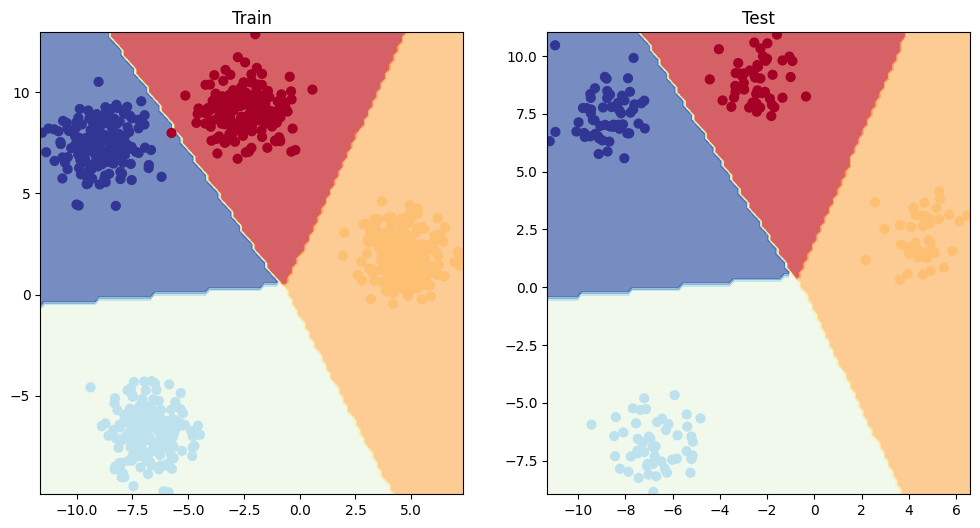

In [18]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(blob_model, X_blob_train, Y_blob_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(blob_model, X_blob_test, Y_blob_test)

## 9. A Few More Classification Metrics... (to evaluate our classification model)

(Date - 10/Apr/2026)

In [19]:
torchmetric_accuracy = Accuracy(task='multiclass', num_classes=4).to(device)
torchmetric_accuracy(y_preds, Y_blob_test)

tensor(1.)